In [1]:
import torch
from torchtext import data

SEED = 1234

torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

TEXT = data.Field(tokenize = 'spacy',
                  tokenizer_language = 'en_core_web_sm',
                  include_lengths = True,
                  pad_first=True)
LABEL = data.LabelField(dtype = torch.float)


In [2]:
from torchtext import datasets

train_data, test_data = datasets.IMDB.splits(TEXT, LABEL)

In [3]:
import random

train_data, valid_data = train_data.split(random_state = random.seed(SEED))

print(f'Number of training examples: {len(train_data)}')
print(f'Number of validation examples: {len(valid_data)}')
print(f'Number of testing examples: {len(test_data)}')

Number of training examples: 17500
Number of validation examples: 7500
Number of testing examples: 25000


In [4]:
MAX_VOCAB_SIZE = 25_000

TEXT.build_vocab(train_data, max_size = MAX_VOCAB_SIZE)
LABEL.build_vocab(train_data)

In [5]:
print(f"Unique tokens in TEXT vocabulary: {len(TEXT.vocab)}")
print(f"Unique tokens in LABEL vocabulary: {len(LABEL.vocab)}")

TEXT.__dict__

Unique tokens in TEXT vocabulary: 25002
Unique tokens in LABEL vocabulary: 2


{'sequential': True,
 'use_vocab': True,
 'init_token': None,
 'eos_token': None,
 'unk_token': '<unk>',
 'fix_length': None,
 'dtype': torch.int64,
 'preprocessing': None,
 'postprocessing': None,
 'lower': False,
 'tokenizer_args': ('spacy', 'en_core_web_sm'),
 'tokenize': functools.partial(<function _spacy_tokenize at 0x0000022175765750>, spacy=<spacy.lang.en.English object at 0x000002217E0F95D0>),
 'include_lengths': True,
 'batch_first': False,
 'pad_token': '<pad>',
 'pad_first': True,
 'truncate_first': False,
 'stop_words': None,
 'is_target': False,
 'vocab': <torchtext.vocab.Vocab at 0x2217f499540>}

In [6]:
BATCH_SIZE = 64

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_iterator, valid_iterator, test_iterator = data.BucketIterator.splits(
    (train_data, valid_data, test_data),
    batch_size = BATCH_SIZE,
    sort_within_batch = True,
    device = device)

In [7]:
import torch.nn as nn
import torch.optim as optim
import time

#count the trainable param
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

#accuracy function
def binary_accuracy(preds, y):
    """
    Returns accuracy per batch, i.e. if you get 8/10 right, this returns 0.8, NOT 8
    """

    #round predictions to the closest integer
    rounded_preds = torch.round(torch.sigmoid(preds))
    correct = (rounded_preds == y).float() #convert into float for division
    acc = correct.sum() / len(correct)
    return acc

def train(model, iterator, optimizer, criterion):

    epoch_loss = 0
    epoch_acc = 0

    model.train()

    for batch in iterator:
        optimizer.zero_grad()
        text, text_lengths = batch.text

        #exchange dim to train the feed-forward NN
        text= text.permute(1, 0)
        #print(text.shape)

        predictions = model(text, text_lengths).squeeze(1)
        #print(predictions.shape)

        loss = criterion(predictions, batch.label)
        acc = binary_accuracy(predictions, batch.label)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

def evaluate(model, iterator, criterion):

    epoch_loss = 0
    epoch_acc = 0
    model.eval()
    with torch.no_grad():
        for batch in iterator:
            text, text_lengths = batch.text

            #exchange dim to train the feed-forward NN
            text= text.permute(1, 0)

            predictions = model(text, text_lengths).squeeze(1)
            loss = criterion(predictions, batch.label)
            acc = binary_accuracy(predictions, batch.label)
            epoch_loss += loss.item()
            epoch_acc += acc.item()
    return epoch_loss / len(iterator), epoch_acc / len(iterator)


def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs



In [8]:
class MLP_one_layer (nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim, output_dim):

        super().__init__()
        self.embedding = nn.Embedding(input_dim, embedding_dim)
        self.mlp1 = nn.Linear(embedding_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, text, text_lengths):
        embedded = self.embedding(text) #word embedding
        #[batch,sentence_lenth,embedding_dim_for_word]

        # use mean value of each word_vec to persent the whole sentence
        sentence_embedding = torch.mean(embedded, dim=1)  # one-layer mlp directly use the whole sentence at once
        #[batch, embedding_dim_for_sentence]

        mlp1_out = self.mlp1(sentence_embedding)
        mlp1_out = torch.relu(mlp1_out) # first later feed-forward with relu

        out= self.fc2(mlp1_out) #full connect out to 1 dim
        #print(out.shape)

        return out

In [9]:
class MLP_TWO_layer (nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim_1,hidden_dim_2, output_dim):

        super().__init__()
        self.embedding = nn.Embedding(input_dim, embedding_dim)
        self.mlp1 = nn.Linear(embedding_dim, hidden_dim_1)
        self.mlp2 = nn.Linear(hidden_dim_1, hidden_dim_2)
        self.fc2 = nn.Linear(hidden_dim_2, output_dim)

    def forward(self, text, text_lengths):
        embedded = self.embedding(text) #word embedding
        #[batch,sentence_lenth,embedding_dim_for_word]

        # use mean value of each word_vec to persent the whole sentence
        sentence_embedding = torch.mean(embedded, dim=1)  # one-layer mlp directly use the whole sentence at once
        #[batch, embedding_dim_for_sentence]

        mlp1_out = self.mlp1(sentence_embedding)
        mlp1_out = torch.relu(mlp1_out) #  feed-forward with relu

        mlp2_out = self.mlp2(mlp1_out)
        mlp2_out = torch.relu(mlp2_out) #  feed-forward with relu

        out= self.fc2(mlp2_out) #full connect out to 1 dim
        #print(out.shape)

        return out

In [10]:
class MLP_THREE_layer (nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim_1,hidden_dim_2,hidden_dim_3, output_dim):

        super().__init__()
        self.embedding = nn.Embedding(input_dim, embedding_dim)
        self.mlp1 = nn.Linear(embedding_dim, hidden_dim_1)
        self.mlp2 = nn.Linear(hidden_dim_1, hidden_dim_2)
        self.mlp3 = nn.Linear(hidden_dim_2, hidden_dim_3)
        self.fc2 = nn.Linear(hidden_dim_3, output_dim)

    def forward(self, text, text_lengths):
        embedded = self.embedding(text) #word embedding
        #[batch,sentence_lenth,embedding_dim_for_word]

        # use mean value of each word_vec to persent the whole sentence
        sentence_embedding = torch.mean(embedded, dim=1)  # one-layer mlp directly use the whole sentence at once
        #[batch, embedding_dim_for_sentence]

        mlp1_out = self.mlp1(sentence_embedding)
        mlp1_out = torch.relu(mlp1_out) #  feed-forward with relu

        mlp2_out = self.mlp2(mlp1_out)
        mlp2_out = torch.relu(mlp2_out) #  feed-forward with relu

        mlp3_out = self.mlp3(mlp2_out)
        mlp3_out = torch.relu(mlp3_out) #  feed-forward with relu

        out= self.fc2(mlp3_out) #full connect out to 1 dim
        #print(out.shape)

        return out

In [12]:
mlp_1=[]
mlp_2=[]
mlp_3=[]

In [13]:
## 1.
##model layers setting
BATCH_SIZE = 64

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_iterator, valid_iterator, test_iterator = data.BucketIterator.splits(
    (train_data, valid_data, test_data),
    batch_size = BATCH_SIZE,
    sort_within_batch = True,
    device = device)

INPUT_DIM_MLP_one_layer = len(TEXT.vocab)
EMBEDDING_DIM_MLP_one_layer = 100
HIDDEN_DIM_MLP_one_layer = 500
OUTPUT_DIM_MLP_one_layer = 1
model_MLP_one_layer = MLP_one_layer(INPUT_DIM_MLP_one_layer, EMBEDDING_DIM_MLP_one_layer, HIDDEN_DIM_MLP_one_layer, OUTPUT_DIM_MLP_one_layer)

#output the trainable param_num
print(f'The model has {count_parameters(model_MLP_one_layer):,} trainable parameters')
#choose the optimizer
optimizer = optim.Adam(model_MLP_one_layer.parameters(), lr=1e-3) #ADAM
## LOSS func
criterion = nn.BCEWithLogitsLoss()
#sent model to GPU
model_MLP_one_layer = model_MLP_one_layer.to(device)
criterion = criterion.to(device)

###### begin training
N_EPOCHS = 50

best_valid_loss = float('inf')

for epoch in range(N_EPOCHS):

    start_time = time.time()

    train_loss, train_acc = train(model_MLP_one_layer, train_iterator, optimizer, criterion)
    valid_loss, valid_acc = evaluate(model_MLP_one_layer, valid_iterator, criterion)

    end_time = time.time()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model_MLP_one_layer.state_dict(), 'tut1-model_MLP_one_layer.pt')

    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')

    mlp_1.append(train_loss)


model_MLP_one_layer.load_state_dict(torch.load('tut1-model_MLP_one_layer.pt'))
test_loss, test_acc = evaluate(model_MLP_one_layer, test_iterator, criterion)
print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

The model has 2,551,201 trainable parameters
Epoch: 01 | Epoch Time: 0m 1s
	Train Loss: 0.549 | Train Acc: 71.86%
	 Val. Loss: 0.438 |  Val. Acc: 80.12%
Epoch: 02 | Epoch Time: 0m 2s
	Train Loss: 0.365 | Train Acc: 84.49%
	 Val. Loss: 0.356 |  Val. Acc: 85.08%
Epoch: 03 | Epoch Time: 0m 2s
	Train Loss: 0.264 | Train Acc: 89.42%
	 Val. Loss: 0.345 |  Val. Acc: 86.21%
Epoch: 04 | Epoch Time: 0m 2s
	Train Loss: 0.216 | Train Acc: 92.56%
	 Val. Loss: 0.297 |  Val. Acc: 88.40%
Epoch: 05 | Epoch Time: 0m 2s
	Train Loss: 0.163 | Train Acc: 94.19%
	 Val. Loss: 0.319 |  Val. Acc: 88.24%
Epoch: 06 | Epoch Time: 0m 2s
	Train Loss: 0.141 | Train Acc: 95.81%
	 Val. Loss: 0.322 |  Val. Acc: 88.63%
Epoch: 07 | Epoch Time: 0m 2s
	Train Loss: 0.114 | Train Acc: 96.75%
	 Val. Loss: 0.343 |  Val. Acc: 88.24%
Epoch: 08 | Epoch Time: 0m 2s
	Train Loss: 0.079 | Train Acc: 98.04%
	 Val. Loss: 0.369 |  Val. Acc: 88.15%
Epoch: 09 | Epoch Time: 0m 2s
	Train Loss: 0.057 | Train Acc: 98.58%
	 Val. Loss: 0.395 |  

In [14]:
## 2.
##model layers setting
BATCH_SIZE = 64

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_iterator, valid_iterator, test_iterator = data.BucketIterator.splits(
    (train_data, valid_data, test_data),
    batch_size = BATCH_SIZE,
    sort_within_batch = True,
    device = device)

INPUT_DIM_MLP_two_layer = len(TEXT.vocab)
EMBEDDING_DIM_MLP_two_layer = 100
HIDDEN_DIM_MLP_two_layer_1 = 500
HIDDEN_DIM_MLP_two_layer_2= 300
OUTPUT_DIM_MLP_two_layer = 1
model_MLP_two_layer = MLP_TWO_layer(INPUT_DIM_MLP_two_layer, EMBEDDING_DIM_MLP_two_layer, HIDDEN_DIM_MLP_two_layer_1,HIDDEN_DIM_MLP_two_layer_2, OUTPUT_DIM_MLP_two_layer)

#output the trainable param_num
print(f'The model has {count_parameters(model_MLP_two_layer):,} trainable parameters')
#choose the optimizer
optimizer = optim.Adam(model_MLP_two_layer.parameters(), lr=1e-3) #ADAM
## LOSS func
criterion = nn.BCEWithLogitsLoss()
#sent model to GPU
model_MLP_two_layer = model_MLP_two_layer.to(device)
criterion = criterion.to(device)

###### begin training
N_EPOCHS = 50

best_valid_loss = float('inf')

for epoch in range(N_EPOCHS):

    start_time = time.time()

    train_loss, train_acc = train(model_MLP_two_layer, train_iterator, optimizer, criterion)
    valid_loss, valid_acc = evaluate(model_MLP_two_layer, valid_iterator, criterion)

    end_time = time.time()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model_MLP_two_layer.state_dict(), 'tut1-model_MLP_two_layer.pt')

    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')

    mlp_2.append(train_loss)

model_MLP_two_layer.load_state_dict(torch.load('tut1-model_MLP_two_layer.pt'))
test_loss, test_acc = evaluate(model_MLP_two_layer, test_iterator, criterion)
print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

The model has 2,701,301 trainable parameters
Epoch: 01 | Epoch Time: 0m 2s
	Train Loss: 0.545 | Train Acc: 71.54%
	 Val. Loss: 0.443 |  Val. Acc: 80.25%
Epoch: 02 | Epoch Time: 0m 2s
	Train Loss: 0.350 | Train Acc: 84.94%
	 Val. Loss: 0.332 |  Val. Acc: 85.50%
Epoch: 03 | Epoch Time: 0m 2s
	Train Loss: 0.247 | Train Acc: 90.10%
	 Val. Loss: 0.333 |  Val. Acc: 85.92%
Epoch: 04 | Epoch Time: 0m 2s
	Train Loss: 0.178 | Train Acc: 93.10%
	 Val. Loss: 0.331 |  Val. Acc: 86.92%
Epoch: 05 | Epoch Time: 0m 2s
	Train Loss: 0.127 | Train Acc: 95.43%
	 Val. Loss: 0.361 |  Val. Acc: 87.13%
Epoch: 06 | Epoch Time: 0m 2s
	Train Loss: 0.090 | Train Acc: 97.06%
	 Val. Loss: 0.429 |  Val. Acc: 87.57%
Epoch: 07 | Epoch Time: 0m 2s
	Train Loss: 0.071 | Train Acc: 97.71%
	 Val. Loss: 0.497 |  Val. Acc: 87.13%
Epoch: 08 | Epoch Time: 0m 2s
	Train Loss: 0.039 | Train Acc: 98.74%
	 Val. Loss: 0.559 |  Val. Acc: 87.16%
Epoch: 09 | Epoch Time: 0m 2s
	Train Loss: 0.030 | Train Acc: 99.04%
	 Val. Loss: 0.604 |  

In [15]:
## 3.
##model layers setting
BATCH_SIZE = 64

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_iterator, valid_iterator, test_iterator = data.BucketIterator.splits(
    (train_data, valid_data, test_data),
    batch_size = BATCH_SIZE,
    sort_within_batch = True,
    device = device)

INPUT_DIM_MLP_three_layer = len(TEXT.vocab)
EMBEDDING_DIM_MLP_three_layer = 100
HIDDEN_DIM_MLP_three_layer_1 = 500
HIDDEN_DIM_MLP_three_layer_2= 300
HIDDEN_DIM_MLP_three_layer_3= 200
OUTPUT_DIM_MLP_three_layer = 1
model_MLP_three_layer = MLP_THREE_layer(INPUT_DIM_MLP_three_layer, EMBEDDING_DIM_MLP_three_layer, HIDDEN_DIM_MLP_three_layer_1,HIDDEN_DIM_MLP_three_layer_2, HIDDEN_DIM_MLP_three_layer_3,OUTPUT_DIM_MLP_three_layer)

#output the trainable param_num
print(f'The model has {count_parameters(model_MLP_three_layer):,} trainable parameters')
#choose the optimizer
optimizer = optim.Adam(model_MLP_three_layer.parameters(), lr=1e-3) #ADAM
## LOSS func
criterion = nn.BCEWithLogitsLoss()
#sent model to GPU
model_MLP_three_layer = model_MLP_three_layer.to(device)
criterion = criterion.to(device)

###### begin training
N_EPOCHS = 50

best_valid_loss = float('inf')

for epoch in range(N_EPOCHS):

    start_time = time.time()

    train_loss, train_acc = train(model_MLP_three_layer, train_iterator, optimizer, criterion)
    valid_loss, valid_acc = evaluate(model_MLP_three_layer, valid_iterator, criterion)

    end_time = time.time()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model_MLP_three_layer.state_dict(), 'tut1-model_MLP_three_layer.pt')

    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')

    mlp_3.append(train_loss)

model_MLP_three_layer.load_state_dict(torch.load('tut1-model_MLP_three_layer.pt'))
test_loss, test_acc = evaluate(model_MLP_three_layer, test_iterator, criterion)
print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

The model has 2,761,401 trainable parameters
Epoch: 01 | Epoch Time: 0m 2s
	Train Loss: 0.544 | Train Acc: 72.08%
	 Val. Loss: 0.430 |  Val. Acc: 80.27%
Epoch: 02 | Epoch Time: 0m 2s
	Train Loss: 0.354 | Train Acc: 84.85%
	 Val. Loss: 0.348 |  Val. Acc: 84.76%
Epoch: 03 | Epoch Time: 0m 2s
	Train Loss: 0.271 | Train Acc: 89.13%
	 Val. Loss: 0.339 |  Val. Acc: 86.13%
Epoch: 04 | Epoch Time: 0m 2s
	Train Loss: 0.196 | Train Acc: 92.61%
	 Val. Loss: 0.375 |  Val. Acc: 86.45%
Epoch: 05 | Epoch Time: 0m 2s
	Train Loss: 0.153 | Train Acc: 95.21%
	 Val. Loss: 0.359 |  Val. Acc: 86.96%
Epoch: 06 | Epoch Time: 0m 2s
	Train Loss: 0.096 | Train Acc: 96.78%
	 Val. Loss: 0.436 |  Val. Acc: 86.58%
Epoch: 07 | Epoch Time: 0m 2s
	Train Loss: 0.067 | Train Acc: 97.95%
	 Val. Loss: 0.474 |  Val. Acc: 87.30%
Epoch: 08 | Epoch Time: 0m 2s
	Train Loss: 0.065 | Train Acc: 97.90%
	 Val. Loss: 0.564 |  Val. Acc: 87.00%
Epoch: 09 | Epoch Time: 0m 2s
	Train Loss: 0.065 | Train Acc: 98.30%
	 Val. Loss: 0.588 |  

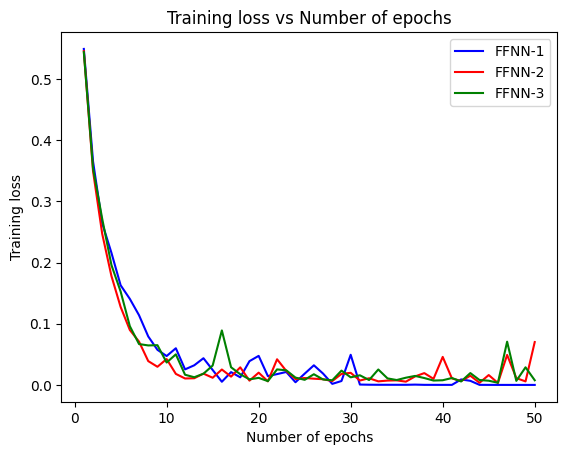

In [19]:
from matplotlib import pyplot as plt

plt.plot(range(1,len(mlp_1)+1), mlp_1, 'b')
plt.plot(range(1,len(mlp_2)+1), mlp_2, 'r')
plt.plot(range(1,len(mlp_3)+1), mlp_3, 'g')
plt.xlabel("Number of epochs")
plt.ylabel("Training loss")

plt.title("Training loss vs Number of epochs")
plt.legend(['FFNN-1', 'FFNN-2', 'FFNN-3'],loc=1)
plt.savefig("Performance with different depth (50 epochs)_ Train loss.png")
plt.show()

In [83]:
class CNN(nn.Module):
    def __init__(self, input_dim, embedding_dim, num_filters, filter_sizes, output_dim):

        super().__init__()
        self.embedding = nn.Embedding(input_dim, embedding_dim)

        '''
        self.convs = nn.ModuleList([
            nn.Conv2d(in_channels=1,
                      out_channels=num_filters,
                      kernel_size=(fs, embedding_dim)) for fs in filter_sizes])
        '''

        self.conv1 = nn.Conv2d(in_channels=1,
                              out_channels=num_filters,
                              kernel_size=(filter_sizes[0], embedding_dim))
        ## [sentence_lenth, embedding_dim_for_word] * [filter_size, embedding_dim_for_word] --> [sentence_lenth-(filter_size-1)]

        self.conv2 = nn.Conv2d(in_channels=1,
                              out_channels=num_filters,
                              kernel_size=(filter_sizes[1], embedding_dim))

        self.conv3 = nn.Conv2d(in_channels=1,
                              out_channels=num_filters,
                              kernel_size=(filter_sizes[2], embedding_dim))

        self.fc = nn.Linear(len(filter_sizes) * num_filters, output_dim)

    def forward(self, text, text_lengths):
        embedded = self.embedding(text) #word embedding
        #[batch,sentence_lenth,embedding_dim_for_word]
        embedded = embedded.unsqueeze(1)
        #[batch_size, 1channel, sentence_lenth, embedding_dim_for_word]

        #three feature maps conv N-GRAM
        conv1_out = torch.relu(self.conv1(embedded)).squeeze(3)
        # [batch_size, num_filters, sentence_lenth-filter_sizes[0]+1]
        pooled1 = torch.max(conv1_out, dim=2)[0]
        # [batch_size, num_filters]

        conv2_out = torch.relu(self.conv2(embedded)).squeeze(3)
        pooled2 = torch.max(conv2_out, dim=2)[0]

        conv3_out = torch.relu(self.conv3(embedded)).squeeze(3)
        pooled3 = torch.max(conv3_out, dim=2)[0]

        # concat all the conv layer
        cat = torch.cat([pooled1, pooled2, pooled3], dim=1)

        out= self.fc(cat) #full connect out to 1 dim
        #print(out.shape)

        return out

In [85]:
## 4.CNN n_gram
##model layers setting
BATCH_SIZE = 64

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_iterator, valid_iterator, test_iterator = data.BucketIterator.splits(
    (train_data, valid_data, test_data),
    batch_size = BATCH_SIZE,
    sort_within_batch = True,
    device = device)

INPUT_DIM_CNN = len(TEXT.vocab)
EMBEDDING_DIM_CNN = 100
NUM_FILTERS = 100
FILTER_SIZES=[1,2,3]
OUTPUT_DIM_CNN = 1
model_CNN = CNN(INPUT_DIM_CNN, EMBEDDING_DIM_CNN, NUM_FILTERS ,FILTER_SIZES, OUTPUT_DIM_CNN)

#output the trainable param_num
print(f'The model has {count_parameters(model_CNN):,} trainable parameters')
#choose the optimizer
optimizer = optim.Adam(model_CNN.parameters(), lr=1e-3) #ADAM
## LOSS func
criterion = nn.BCEWithLogitsLoss()
#sent model to GPU
model_CNN = model_CNN.to(device)
criterion = criterion.to(device)

###### begin training
N_EPOCHS = 50

best_valid_loss = float('inf')

for epoch in range(N_EPOCHS):

    start_time = time.time()

    train_loss, train_acc = train(model_CNN, train_iterator, optimizer, criterion)
    valid_loss, valid_acc = evaluate(model_CNN, valid_iterator, criterion)

    end_time = time.time()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model_CNN.state_dict(), 'tut1-model_CNN.pt')

    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')


model_CNN.load_state_dict(torch.load('tut1-model_CNN.pt'))
test_loss, test_acc = evaluate(model_CNN, test_iterator, criterion)
print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

The model has 2,560,801 trainable parameters
Epoch: 01 | Epoch Time: 0m 7s
	Train Loss: 0.505 | Train Acc: 75.53%
	 Val. Loss: 0.401 |  Val. Acc: 82.04%
Epoch: 02 | Epoch Time: 0m 7s
	Train Loss: 0.311 | Train Acc: 87.59%
	 Val. Loss: 0.317 |  Val. Acc: 86.56%
Epoch: 03 | Epoch Time: 0m 7s
	Train Loss: 0.217 | Train Acc: 92.17%
	 Val. Loss: 0.296 |  Val. Acc: 87.11%
Epoch: 04 | Epoch Time: 0m 7s
	Train Loss: 0.150 | Train Acc: 95.40%
	 Val. Loss: 0.288 |  Val. Acc: 87.65%
Epoch: 05 | Epoch Time: 0m 6s
	Train Loss: 0.090 | Train Acc: 98.25%
	 Val. Loss: 0.286 |  Val. Acc: 87.94%
Epoch: 06 | Epoch Time: 0m 6s
	Train Loss: 0.052 | Train Acc: 99.55%
	 Val. Loss: 0.297 |  Val. Acc: 88.51%
Epoch: 07 | Epoch Time: 0m 6s
	Train Loss: 0.029 | Train Acc: 99.93%
	 Val. Loss: 0.304 |  Val. Acc: 88.46%
Epoch: 08 | Epoch Time: 0m 6s
	Train Loss: 0.017 | Train Acc: 99.98%
	 Val. Loss: 0.311 |  Val. Acc: 88.58%
Epoch: 09 | Epoch Time: 0m 7s
	Train Loss: 0.011 | Train Acc: 100.00%
	 Val. Loss: 0.322 | 

In [98]:
class LSTM(nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim, output_dim, bidirectional=False):

        super().__init__()
        self.embedding = nn.Embedding(input_dim, embedding_dim)

        self.lstm = nn.LSTM(
            embedding_dim, #输入数据的特征维度
            hidden_dim, #隐藏状态 h 的特征维度
            num_layers= 1, #single_layer LSTM
            bidirectional=bidirectional,
            batch_first=True  # 输入格式为 [batch_size, seq_len, features]
        )

        # 双向LSTM的输出维度是 hidden_dim * 2
        lstm_output_dim = hidden_dim * 2 if bidirectional else hidden_dim

        self.fc = nn.Linear(lstm_output_dim, output_dim)

    def forward(self, text, text_lengths):
        embedded = self.embedding(text) #word embedding
        #[batch,sentence_lenth,embedding_dim_for_word]

        lstm_out, (hidden, cell) = self.lstm(embedded)

        # 对于双向LSTM，取最后时刻的前向和后向隐藏状态拼接
        if self.lstm.bidirectional:
            # hidden的形状: [num_layers * num_directions, batch_size, hidden_dim]
            # 取最后一层的前向和后向隐藏状态
            hidden_forward = hidden[-2, :, :]  # 前向最后一个时间步
            hidden_backward = hidden[-1, :, :]  # 后向最后一个时间步
            # 拼接 [batch_size, hidden_dim * 2]
            hidden_concat = torch.cat((hidden_forward, hidden_backward), dim=1)
        else:
            # 单向LSTM，取最后一层的隐藏状态
            hidden_concat = hidden[-1, :, :]

        out= self.fc(hidden_concat) #full connect out to 1 dim
        #print(out.shape)

        return out

In [102]:
## 4.LSTM
##model layers setting
BATCH_SIZE = 64

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_iterator, valid_iterator, test_iterator = data.BucketIterator.splits(
    (train_data, valid_data, test_data),
    batch_size = BATCH_SIZE,
    sort_within_batch = True,
    device = device)

INPUT_DIM_LSTM = len(TEXT.vocab)
EMBEDDING_DIM_LSTM = 100
HIDDEN_DIM = 200
OUTPUT_DIM_LSTM = 1
bidirectional=False
model_LSTM = LSTM(INPUT_DIM_LSTM, EMBEDDING_DIM_LSTM, HIDDEN_DIM , OUTPUT_DIM_LSTM, bidirectional)

#output the trainable param_num
print(f'The model has {count_parameters(model_LSTM):,} trainable parameters')
#choose the optimizer
optimizer = optim.Adam(model_LSTM.parameters(), lr=1e-3) #ADAM
## LOSS func
criterion = nn.BCEWithLogitsLoss()
#sent model to GPU
model_LSTM = model_LSTM.to(device)
criterion = criterion.to(device)

###### begin training
N_EPOCHS = 50

best_valid_loss = float('inf')

for epoch in range(N_EPOCHS):

    start_time = time.time()

    train_loss, train_acc = train(model_LSTM, train_iterator, optimizer, criterion)
    valid_loss, valid_acc = evaluate(model_LSTM, valid_iterator, criterion)

    end_time = time.time()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model_LSTM.state_dict(), 'tut1-model_LSTM.pt')

    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')


model_LSTM.load_state_dict(torch.load('tut1-model_LSTM.pt'))
test_loss, test_acc = evaluate(model_LSTM, test_iterator, criterion)
print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

The model has 2,742,001 trainable parameters
Epoch: 01 | Epoch Time: 0m 6s
	Train Loss: 0.644 | Train Acc: 62.52%
	 Val. Loss: 0.588 |  Val. Acc: 69.04%
Epoch: 02 | Epoch Time: 0m 6s
	Train Loss: 0.632 | Train Acc: 64.74%
	 Val. Loss: 0.652 |  Val. Acc: 61.80%
Epoch: 03 | Epoch Time: 0m 6s
	Train Loss: 0.554 | Train Acc: 71.41%
	 Val. Loss: 0.479 |  Val. Acc: 77.89%
Epoch: 04 | Epoch Time: 0m 6s
	Train Loss: 0.345 | Train Acc: 85.35%
	 Val. Loss: 0.348 |  Val. Acc: 85.00%
Epoch: 05 | Epoch Time: 0m 6s
	Train Loss: 0.236 | Train Acc: 90.96%
	 Val. Loss: 0.327 |  Val. Acc: 86.51%
Epoch: 06 | Epoch Time: 0m 6s
	Train Loss: 0.161 | Train Acc: 94.38%
	 Val. Loss: 0.344 |  Val. Acc: 87.53%
Epoch: 07 | Epoch Time: 0m 6s
	Train Loss: 0.105 | Train Acc: 96.84%
	 Val. Loss: 0.408 |  Val. Acc: 87.12%
Epoch: 08 | Epoch Time: 0m 6s
	Train Loss: 0.069 | Train Acc: 98.03%
	 Val. Loss: 0.422 |  Val. Acc: 87.52%
Epoch: 09 | Epoch Time: 0m 6s
	Train Loss: 0.049 | Train Acc: 98.65%
	 Val. Loss: 0.443 |  

In [104]:
## 4.BI-LSTM
##model layers setting
BATCH_SIZE = 64

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_iterator, valid_iterator, test_iterator = data.BucketIterator.splits(
    (train_data, valid_data, test_data),
    batch_size = BATCH_SIZE,
    sort_within_batch = True,
    device = device)

INPUT_DIM_BILSTM = len(TEXT.vocab)
EMBEDDING_DIM_BILSTM = 100
HIDDEN_DIM = 200
OUTPUT_DIM_BILSTM = 1
bidirectional=True
model_BILSTM = LSTM(INPUT_DIM_BILSTM, EMBEDDING_DIM_BILSTM, HIDDEN_DIM , OUTPUT_DIM_BILSTM, bidirectional)

#output the trainable param_num
print(f'The model has {count_parameters(model_BILSTM):,} trainable parameters')
#choose the optimizer
optimizer = optim.Adam(model_BILSTM.parameters(), lr=1e-3) #ADAM
## LOSS func
criterion = nn.BCEWithLogitsLoss()
#sent model to GPU
model_BILSTM = model_BILSTM.to(device)
criterion = criterion.to(device)

###### begin training
N_EPOCHS = 50

best_valid_loss = float('inf')

for epoch in range(N_EPOCHS):

    start_time = time.time()

    train_loss, train_acc = train(model_BILSTM, train_iterator, optimizer, criterion)
    valid_loss, valid_acc = evaluate(model_BILSTM, valid_iterator, criterion)

    end_time = time.time()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model_BILSTM.state_dict(), 'tut1-model_BILSTM.pt')

    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')


model_BILSTM.load_state_dict(torch.load('tut1-model_BILSTM.pt'))
test_loss, test_acc = evaluate(model_BILSTM, test_iterator, criterion)
print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

The model has 2,983,801 trainable parameters
Epoch: 01 | Epoch Time: 0m 16s
	Train Loss: 0.664 | Train Acc: 58.73%
	 Val. Loss: 0.590 |  Val. Acc: 68.91%
Epoch: 02 | Epoch Time: 0m 15s
	Train Loss: 0.594 | Train Acc: 67.93%
	 Val. Loss: 0.682 |  Val. Acc: 58.01%
Epoch: 03 | Epoch Time: 0m 15s
	Train Loss: 0.545 | Train Acc: 72.32%
	 Val. Loss: 0.482 |  Val. Acc: 77.54%
Epoch: 04 | Epoch Time: 0m 15s
	Train Loss: 0.343 | Train Acc: 85.09%
	 Val. Loss: 0.359 |  Val. Acc: 85.12%
Epoch: 05 | Epoch Time: 0m 15s
	Train Loss: 0.229 | Train Acc: 91.04%
	 Val. Loss: 0.331 |  Val. Acc: 87.42%
Epoch: 06 | Epoch Time: 0m 15s
	Train Loss: 0.156 | Train Acc: 94.39%
	 Val. Loss: 0.351 |  Val. Acc: 87.56%
Epoch: 07 | Epoch Time: 0m 14s
	Train Loss: 0.105 | Train Acc: 96.52%
	 Val. Loss: 0.394 |  Val. Acc: 87.50%
Epoch: 08 | Epoch Time: 0m 15s
	Train Loss: 0.061 | Train Acc: 98.24%
	 Val. Loss: 0.420 |  Val. Acc: 87.88%
Epoch: 09 | Epoch Time: 0m 14s
	Train Loss: 0.043 | Train Acc: 98.77%
	 Val. Loss: 